In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025full.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395695 entries, 0 to 4395694
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Год              float64
 1   Цена             float64
 2   Объем двигателя  float64
 3   Тип двигателя    object 
 4   Мощность         float64
 5   Коробка передач  object 
 6   Привод           object 
 7   Пробег           float64
 8   Поколение        float64
 9   Тип кузова       object 
 10  Метка            object 
 11  Город            object 
 12  Год объявления   int64  
 13  Возраст авто     float64
 14  Модель           object 
dtypes: float64(7), int64(1), object(7)
memory usage: 503.0+ MB


In [4]:
df.shape

(4395695, 15)

In [5]:
df.head()

,Год,Цена,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Поколение,Тип кузова,Метка,Город,Год объявления,Возраст авто,Модель
0,2005.0,1900000.0,5.9,бензин,456.0,АКПП,задний,48000.0,1.0,купе,aston_martin,Москва,2019,14.0,DB9
1,2007.0,1971000.0,5.9,бензин,456.0,АКПП,задний,30000.0,1.0,купе,aston_martin,Ставрополь,2019,12.0,DB9
2,2005.0,2900000.0,5.9,бензин,456.0,АКПП,задний,60000.0,1.0,купе,aston_martin,Краснодар,2020,15.0,DB9
3,2006.0,1650000.0,5.9,бензин,456.0,АКПП,задний,38000.0,1.0,открытый,aston_martin,Москва,2021,15.0,DB9
4,2005.0,2950000.0,5.9,бензин,456.0,АКПП,задний,30000.0,1.0,открытый,aston_martin,Сочи,2021,16.0,DB9


In [6]:
# сокращенный датасет для визуализации
df_eda = df.sample(n=300_000, random_state=42)

In [7]:
categories = ['Тип двигателя', 'Коробка передач', 'Привод', 'Тип кузова', 'Метка', 'Город', 'Модель']
label_encoder = LabelEncoder()
df_eda_encode = df_eda.copy() # сделаем закодированную копию датасета только для матрицы

for col in categories:
    df_eda_encode[col] = label_encoder.fit_transform(df_eda_encode[col])

<Axes: >

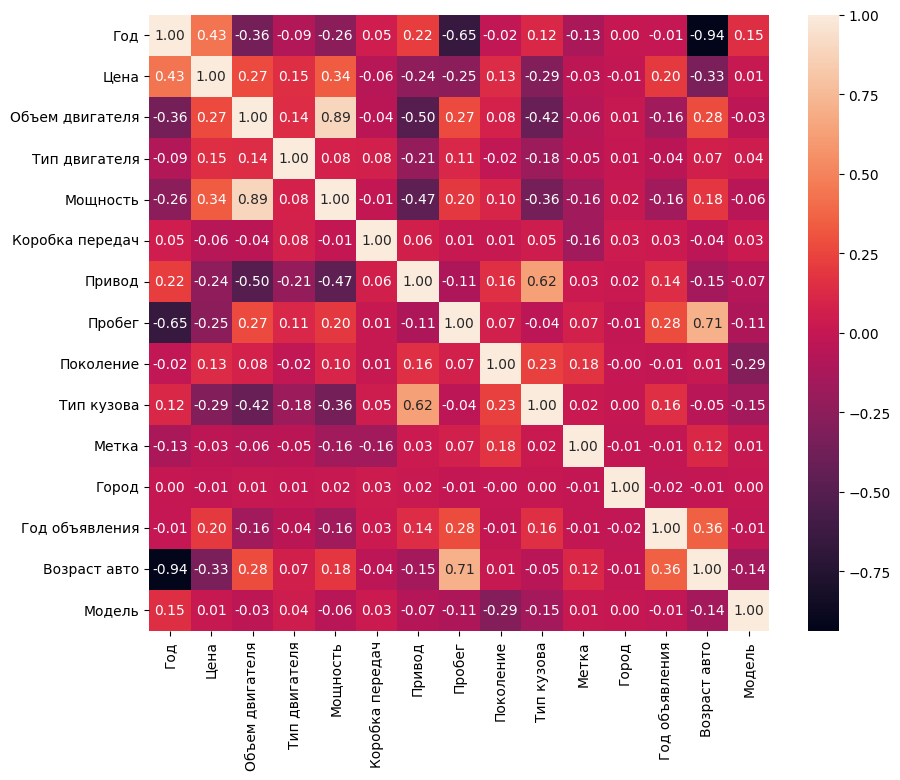

In [8]:
corr_matrix = df_eda_encode.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')

Text(0, 0.5, 'Количество автомобилей')

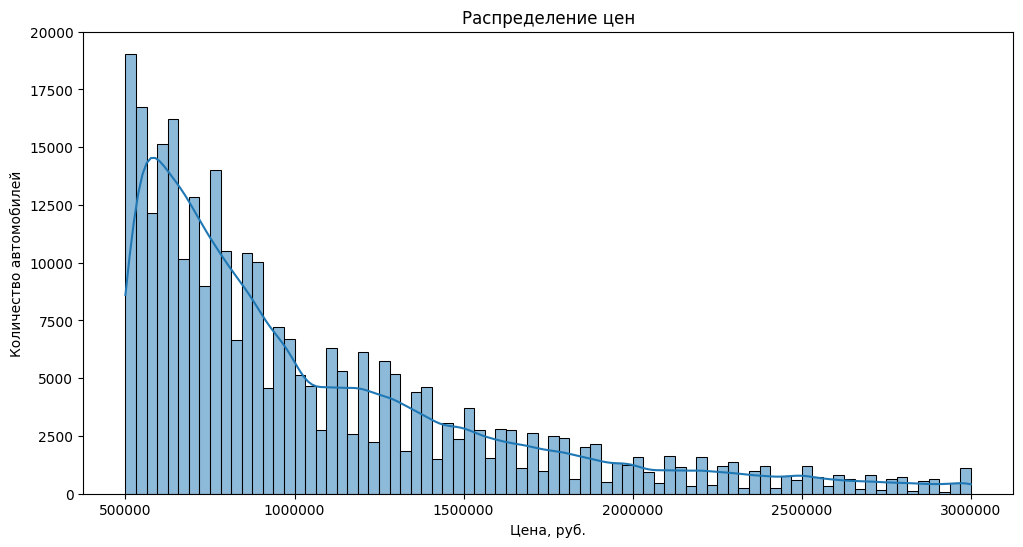

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df_eda["Цена"], bins=80, kde=True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Распределение цен')
plt.xlabel("Цена, руб.")
plt.ylabel("Количество автомобилей")

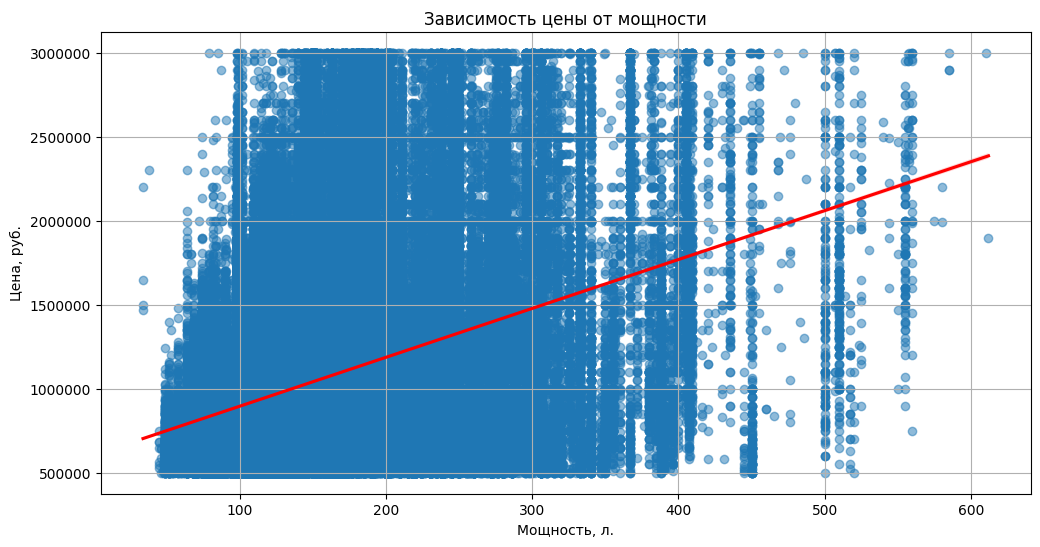

In [10]:
plt.figure(figsize=(12,6))
sns.regplot(x='Мощность', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от мощности')
plt.xlabel("Мощность, л.")
plt.ylabel("Цена, руб.")
plt.grid(True)

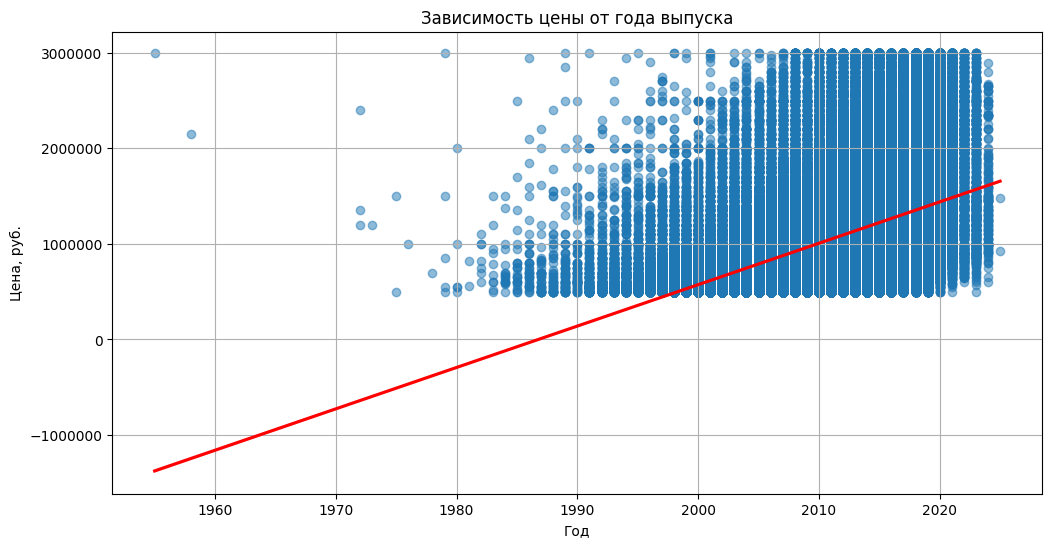

In [11]:
plt.figure(figsize=(12,6))
sns.regplot(x='Год', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от года выпуска')
plt.xlabel("Год")
plt.ylabel("Цена, руб.")
plt.grid(True)

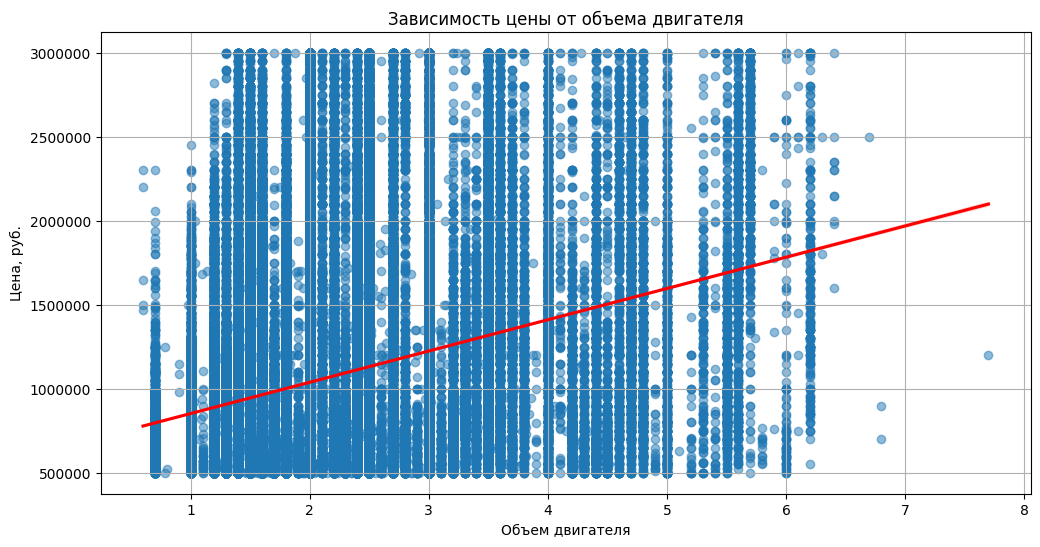

In [12]:
plt.figure(figsize=(12,6))
sns.regplot(x='Объем двигателя', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от объема двигателя')
plt.xlabel("Объем двигателя")
plt.ylabel("Цена, руб.")
plt.grid(True)

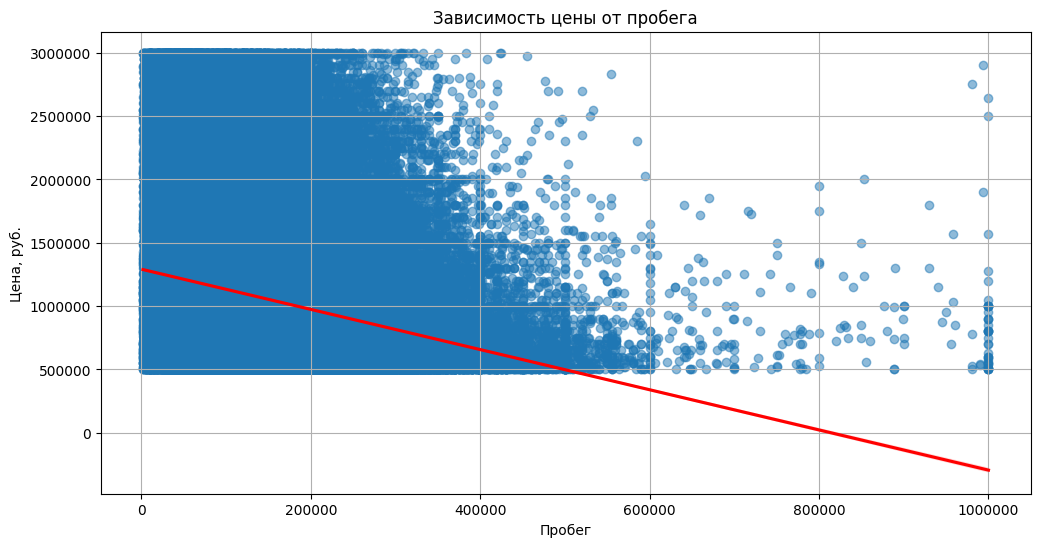

In [13]:
plt.figure(figsize=(12,6))
sns.regplot(x='Пробег', y='Цена', data=df_eda, scatter_kws={'alpha': 0.5}, line_kws={"color":"red"})
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Зависимость цены от пробега')
plt.xlabel("Пробег")
plt.ylabel("Цена, руб.")
plt.grid(True)

Text(0, 0.5, 'Цена, руб.')

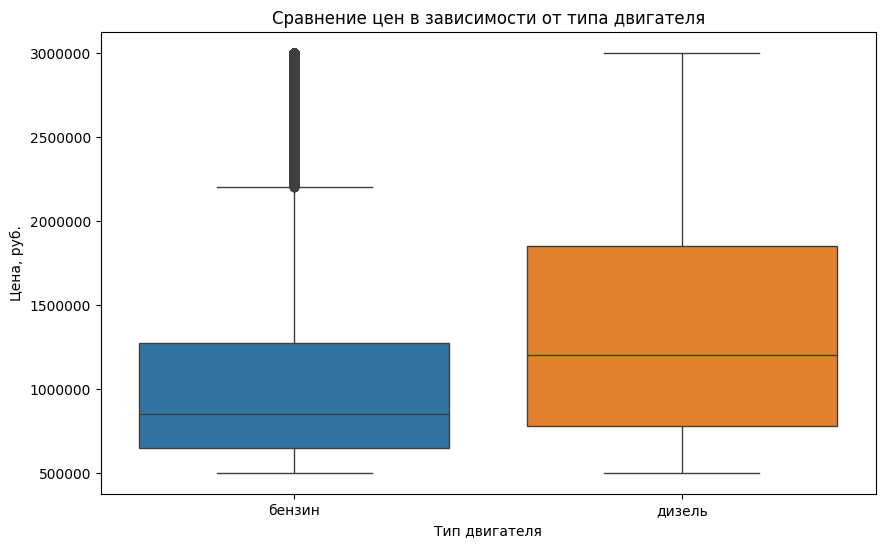

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Тип двигателя', y='Цена', data=df_eda, hue='Тип двигателя')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа двигателя')
plt.xlabel("Тип двигателя")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

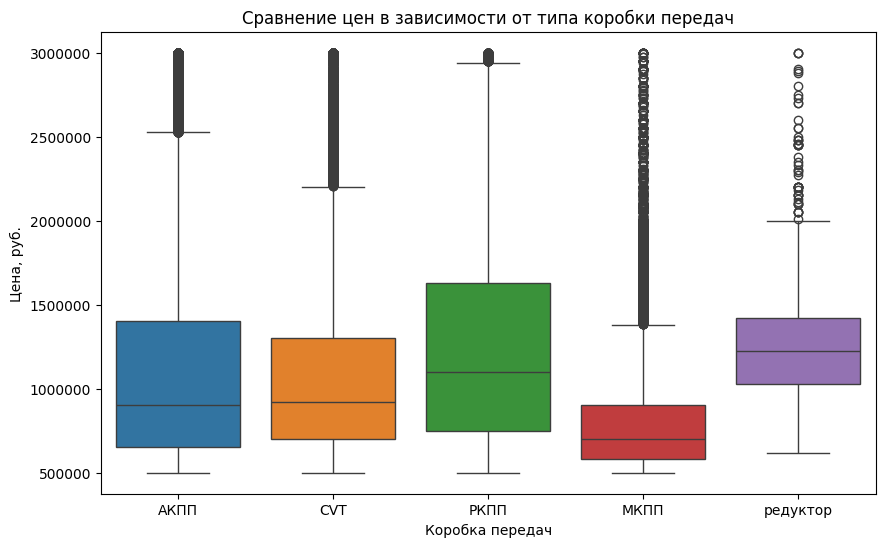

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Коробка передач', y='Цена', data=df_eda, hue='Коробка передач')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа коробки передач')
plt.xlabel("Коробка передач")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

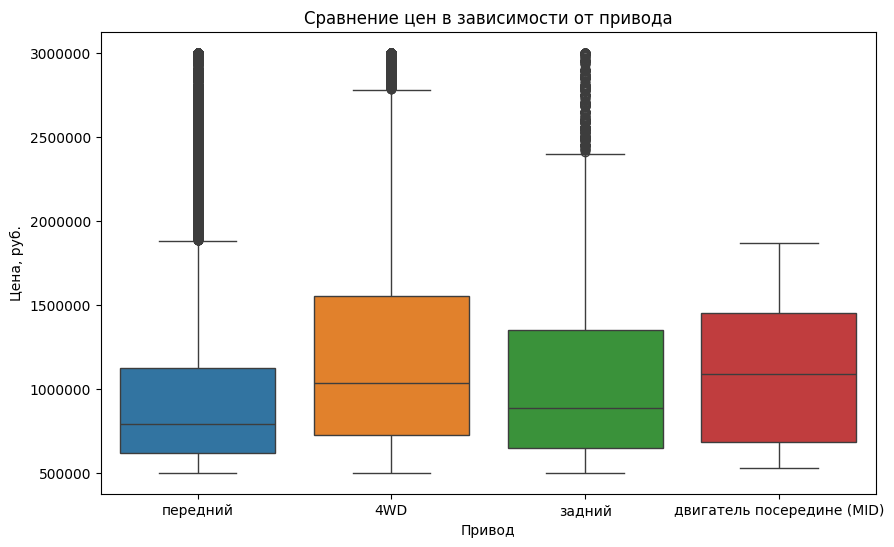

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Привод', y='Цена', data=df_eda, hue='Привод')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от привода')
plt.xlabel("Привод")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

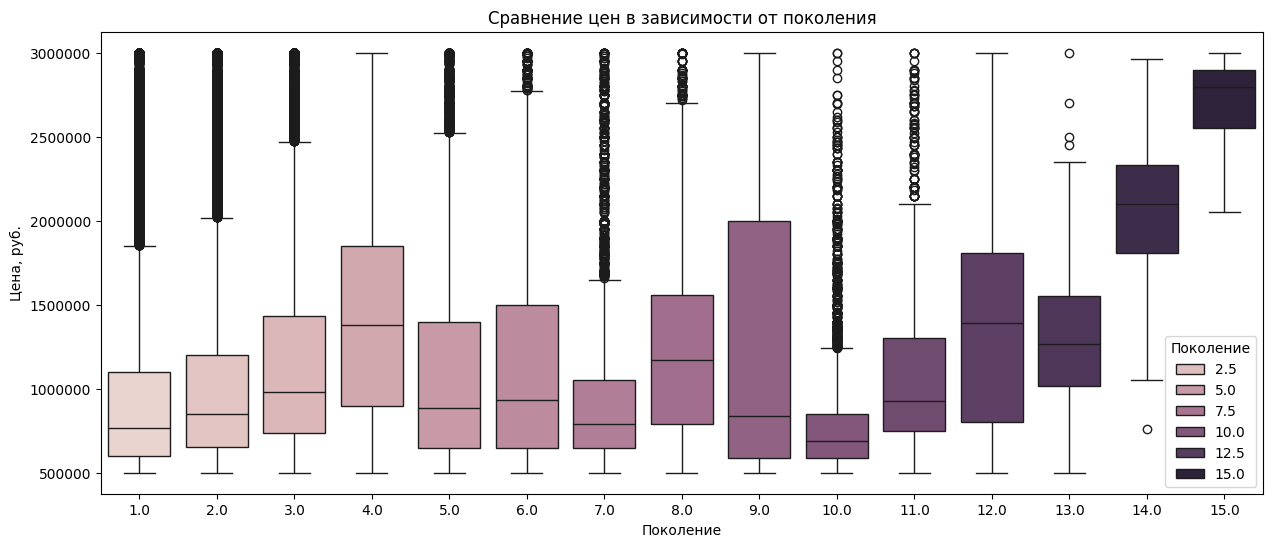

In [17]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Поколение', y='Цена', data=df_eda, hue='Поколение')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от поколения')
plt.xlabel("Поколение")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

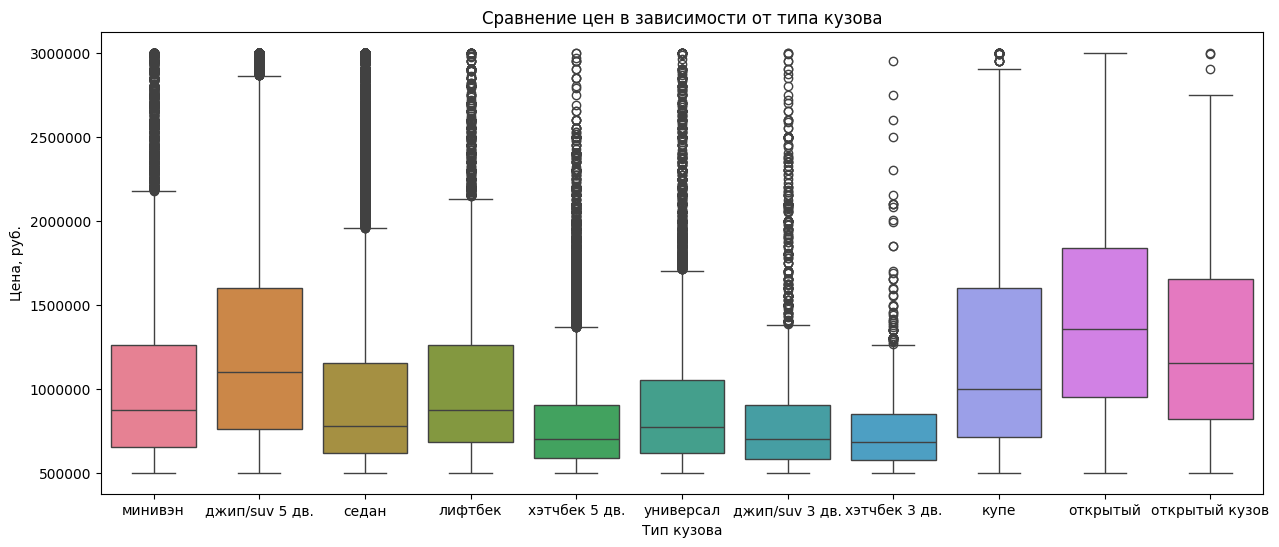

In [18]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Тип кузова', y='Цена', data=df_eda, hue='Тип кузова')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от типа кузова')
plt.xlabel("Тип кузова")
plt.ylabel("Цена, руб.")

Text(0, 0.5, 'Цена, руб.')

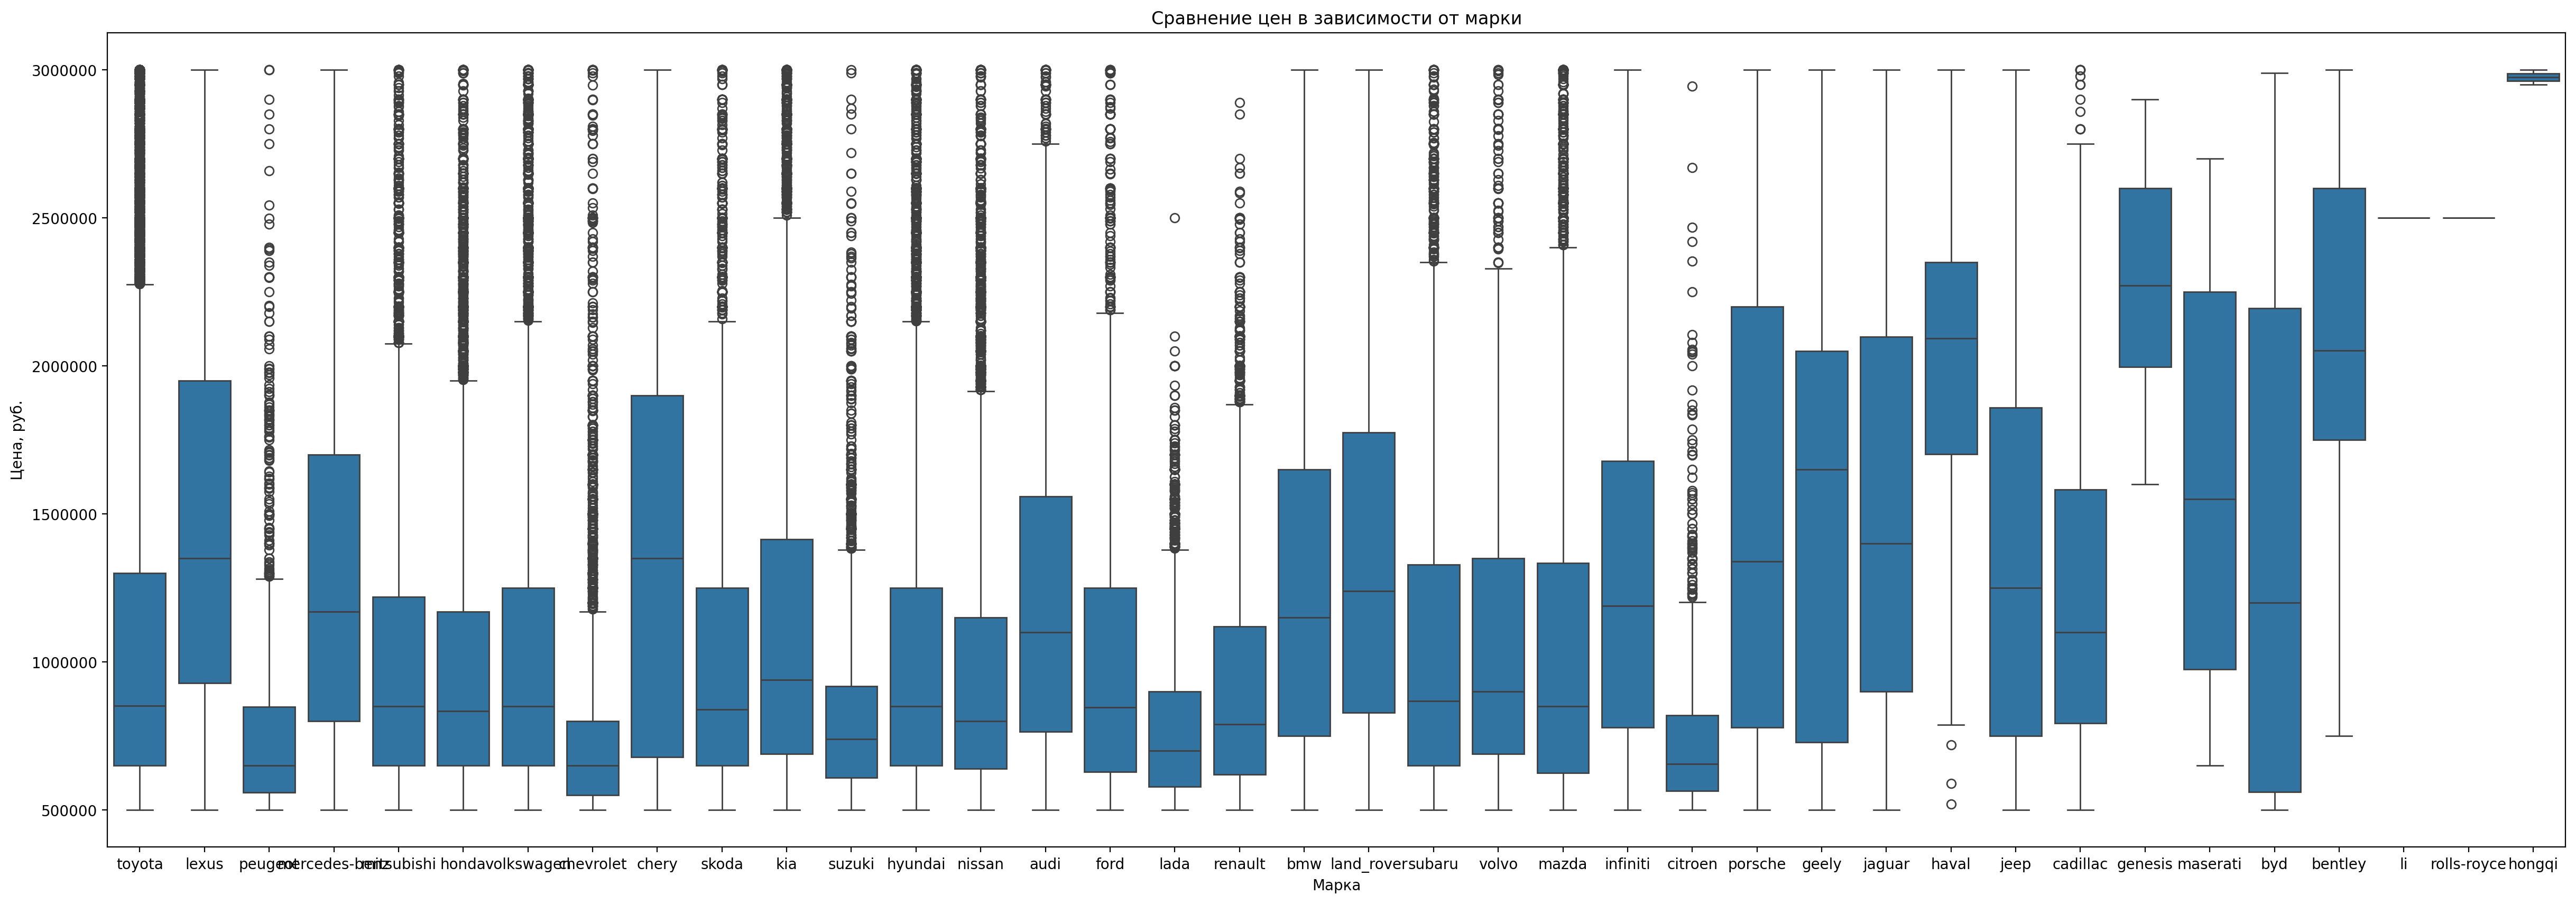

In [19]:
plt.figure(figsize=(30,10), dpi=200)
sns.boxplot(x='Метка', y='Цена', data=df_eda)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Сравнение цен в зависимости от марки')
plt.xlabel("Марка")
plt.ylabel("Цена, руб.")